(2, 4)
40000
theta [-0.50231861  1.00667646]
b -1.5099999999999898


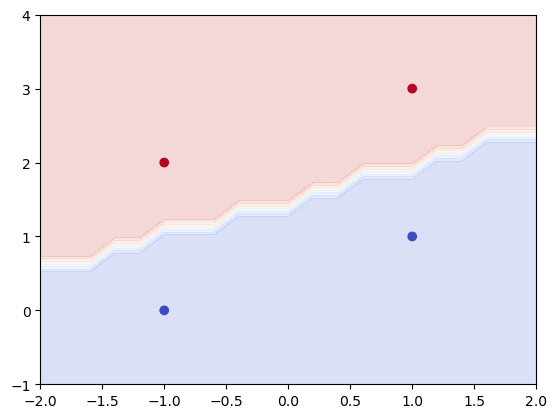

In [115]:
#https://www.geeksforgeeks.org/machine-learning/implementing-svm-from-scratch-in-python/ (helpfull reference for

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



#SVM uses a geometrical margin
#Defining intial 
x = np.array([[1,3],[-1,2],[1,1],[-1,0]])
x = x.T
y = np.array([1,1,-1,-1])

print(x.shape)
#Our parameters
theta = np.array([-1,1])
b = 1



def f(x,theta,b):
    res = theta @ x + b
    #print(res)
    return res



def y_0(z):
    m = len(z)
    y = np.zeros(m)
    for i in range(m):
        if z[i]>=0:
            y[i]=1
        if z[i]<0:
            y[i]=-1
    return y


def magnitude(z):
    res = sum(z**2)
    res = np.sqrt(res)
    return res



def gamma(x,theta,b):
    mag = np.clip(magnitude(theta),1e-7, None)
    res = y_0(f(x,theta,b)) / mag
    return res


#To find optimum value of border we wamt to find
#max gamma given w,b s.t
#y(i)*f(x,theta,b)>=gamma|w|
#Or gamma(x,theta,b) > 

#if y[i] * f(x)[i] >= 1:

## We want to minimise ||W||
#y_i here is the true data
## While maintaining y_i * f(x_I) >= 1 for every i
#Using hinge loss here

rate = 1
lam = 1

# for i (we run condition for evey point)

# print(theta)



def fit(x,y,rate = 0.005, lam = 0.01, iterations = 10000):
    features, samples = x.shape
    theta = np.zeros(features)
    b = 0
    count = 0
    for j in range(iterations):
        for i in range(samples): 
            count += 1
            if y[i] * f(x,theta,b)[i] >= 1: #Here i sample
                theta = theta - rate * 2 * lam * theta
                #print(1)
            else:
                theta = theta - rate * (2 * lam * theta - np.dot(x[:,i],y[i])) 
                b = b + rate * y[i]
            #print(2)
        #print(b,'b for ',j)
    print(count)
    return theta, b

#Having lam be lower than rate should help b to more acurate

theta, b = fit(x,y)
print('theta', theta)
print('b', b)


x=x.T
x0_min, x0_max = x[:,0].min()-1 , x[:,0].max()+1
x1_min, x1_max = x[:,1].min()-1 , x[:,1].max()+1



z1 = np.linspace(x0_min, x0_max, 21)
z2 = np.linspace(x1_min, x1_max, 21)
Z1, Z2 = np.meshgrid(z1,z2)
Z3 = np.c_[Z1.ravel(),Z2.ravel()]

y_mesh = gamma(Z3.T,theta,b)
y_mesh = y_mesh.reshape(Z1.shape)



plt.contourf(Z1, Z2, y_mesh, cmap="coolwarm", alpha=0.2)
#print('x',x.shape)
#print('y',y.shape)

plt.scatter(x[:,0] , x[:,1], c=y, cmap="coolwarm")
plt.xlim(x0_min, x0_max)
plt.ylim(x1_min, x1_max)
plt.show()




[[17.99 20.57 19.69 ... 16.6  20.6   7.76]
 [10.38 17.77 21.25 ... 28.08 29.33 24.54]]
(2, 569)
[[ 2.99  5.57  4.69 ...  1.6   5.6  -7.24]
 [-9.62 -2.23  1.25 ...  8.08  9.33  4.54]]
284500
theta [-0.43254466 -0.07654224] b 0.26788000000018525
(21, 21)


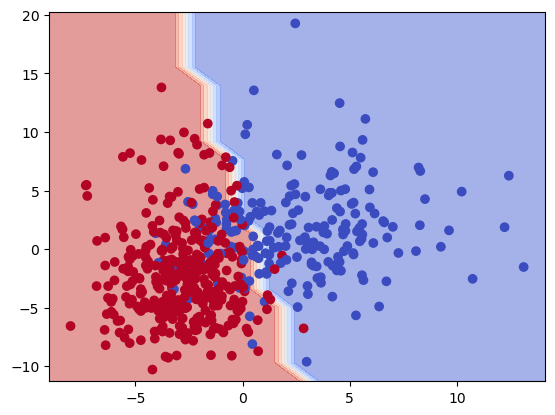

In [106]:
##Applying to realworld data set
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

x = data.data
y = data.target


x = x[:,0:2]
x=x.T
print(x)
print(x.shape)

add = np.array([[-15],[-20]]) #Trying to normalise around origin to make finding easier
x = x + add

print(x)

# Rough formula: iterations * samples = num (so 500*569 roughly = 250000)
# rate = 1/num lam = 1/m adust roiughlt from there ( 4e-6)
theta, b = fit(x,y, rate = 0.000004, lam=0.000004 ,iterations=500)


print('theta',theta,'b',b)

x=x.T
x0_min, x0_max = x[:,0].min()-1 , x[:,0].max()+1
x1_min, x1_max = x[:,1].min()-1 , x[:,1].max()+1


z1 = np.linspace(x0_min, x0_max, 21)
z2 = np.linspace(x1_min, x1_max, 21)
Z1, Z2 = np.meshgrid(z1,z2)
Z3 = np.c_[Z1.ravel(),Z2.ravel()]

y_mesh = gamma(Z3.T,theta,b)
y_mesh = y_mesh.reshape(Z1.shape)
print(y_mesh.shape)



plt.contourf(Z1, Z2, y_mesh, cmap="coolwarm", alpha=0.5)
plt.scatter(x[:,0] , x[:,1], c=y, cmap="coolwarm")
plt.xlim(x0_min, x0_max)
plt.ylim(x1_min, x1_max)
plt.show()

